In [122]:
import torch
from torch_geometric.transforms import BaseTransform, Compose

from torch_geometric.datasets import QM9
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, GATConv
import torch.nn.functional as f
from torch.nn import Linear, ReLU

from torch_geometric.nn import global_mean_pool
from matplotlib import pyplot as plt

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [123]:
qm9 = QM9(root='data')

In [ ]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Using", device)
device = torch.device("mps" if torch.cuda.is_available() else "cpu")
print('using', device)

using cpu


In [125]:
class SetTarget(BaseTransform):
    '''
    Transform to modify target vector so there is a single value.

    Choose from 0-18 for target values described here:
    https://pytorch-geometric.readthedocs.io/en/latest/generated/torch_geometric.datasets.QM9.html#torch_geometric.datasets.QM9
    '''
    def __init__(self,target):
        self.target = target

    def __call__(self,data):
        data.y = data.y[:,self.target]
        return data

class NormalizeTarget(BaseTransform):
    '''
    Transform to normalize target vector.

    Parameters:
    ----------
    mean : mean of the training data target values
    std : standard deviation of the training data target values

    '''
    def __init__(self, mean, std):
        self.mean = mean
        self.std = std

    def __call__(self, data):
        data.y = (data.y - self.mean) / self.std
        return data

In [126]:
def plot_pred_v_actual(preds, actual, title=''):
    '''
    Plot predicted vs actual/expected values as a scatter plot

    Parameters:
    ----------
    preds : numpy array
            predicted values
    actual : numpy array
            expected values
    title : string
            Title for plot (optional)
    '''
    fig, ax = plt.subplots(figsize=(10,7.5))

    # Set the default text font size
    plt.rc('figure', titlesize=16)
    plt.rc('font', size=12)

    min_val = min(min(preds), min(actual))
    max_val = max(max(preds), max(actual))
    lims = [min_val, max_val]

    # now plot both limits against eachother
    ax.plot(lims, lims, 'k--', alpha=0.75)

    ax.set_aspect('equal')
    ax.set_xlim(lims)
    ax.set_ylim(lims)

    ax.scatter(actual, preds, s=20)

    if title == '':
        ax.set_title("Predicted vs Actuals")
    else:
        ax.set_title(title)

    plt.xlabel("actual")
    plt.ylabel("predicted")

    plt.show()


def plot_losses(tlosses, vlosses):
    '''
    Plot training and validation losses per epoch
    Expectation is that losses are ordered starting with same epoch (0)

    Parameters:
    ----------
    tlosses : list of floats
                training loss values
    vlosses : list of floats
                validation loss values

    '''
    plt.figure(figsize=(10,5))
    plt.plot(tlosses, label = "Training", c='r')
    plt.plot(vlosses, label = "Validation", c='b')
    plt.legend()
    plt.ylabel("Loss")
    plt.xlabel("Epoch")
    plt.title("Training and Validation Loss")
    plt.show()

In [127]:
#shuffle first so we get a nice variety
qm9 = qm9.shuffle()
#qm9.data.to(device)

# let's use 20k, and split to train/val/test 70/10/20
sample_count = 58000
train_end = int(sample_count * 0.7)
val_end = train_end + int(sample_count* 0.1)
test_end = val_end + int(sample_count * 0.2)

# normalizing the target values can help when using neural networks, let's do that
# collect the target y values from the training to use for normalizing
train_y2 =torch.cat([qm9[i].y for i in range(train_end)], dim=0)

# compute mean and standard deviation
train_mean = train_y2.mean()
train_std = train_y2.std()

# We are going set our prediction target variable here and also normalize in the transform:
# 11 = Heat capacity at 298.15K
# target_index = 11

#mu
target_index = 0

# transform values
qm9.transform = Compose([SetTarget(target_index),NormalizeTarget(train_mean, train_std)])


# use the DataLoader
# set the batch size
batch = 50
# here we need a cpu device for the generator or collab will complain
gen = torch.Generator(device='cpu')
train_loader = DataLoader(qm9[:train_end], batch_size = batch, shuffle = True, generator=gen)
val_loader = DataLoader(qm9[train_end:val_end], batch_size = batch, shuffle = True, generator=gen)
test_loader = DataLoader(qm9[val_end:test_end], batch_size = batch, shuffle = False, generator=gen)

In [128]:
class GCN(torch.nn.Module):
    '''
    Graph Convolutional Network

    '''
    def __init__(self,num_features, h):
        '''
        Init for GCN class

        Parameters:
        num_features : integer
                     number of features from the data
        h : integer
            number of hidden layers

        '''
        super().__init__()
        self.conv1 = GCNConv(num_features, h)
        self.conv2 = GCNConv(h, h)
        self.linear = Linear(h, 1)

    def forward(self, data):
        e = data.edge_index
        x = data.x

        x = self.conv1(x, e)
        x = x.relu()
        x = self.conv2(x, e)
        x = global_mean_pool(x, data.batch)

        x = f.dropout(x, p=0.25, training=self.training)
        x = self.linear(x)

        return x

In [129]:
def train_model(model, epochs, loss_function, optimizer, train_loader, val_loader):
    '''
    Train the model

    Parameters:
    ----------
    model : nn model to train

    epochs : integer
            number of epochs to train the model

    loss_function : function to evaluate model performance

    optimizer : optimizer to use during training

    train_loader : dataloader containing training data

    val_loader : dataloader containing validation data

    device : where to run

    Returns:
    -------
    model : trained model

    tlosses: list containing floats
            training losses from each epoch

    vlosses : list containing floats
            validation losses from each epoch
    '''
    tlosses = []
    vlosses = []

    for epoch in range(epochs):
        # need model in training mode
        model.train()
        device = next(model.parameters()).device
        tloss = 0
        for data in train_loader:
            #data.x = data.x.float()
            data = data.to(device)
            # forward step of model training
            out = model(data)
            loss = loss_function(out, torch.reshape(data.y, (len(data.y), 1)))
            tloss += loss/len(train_loader)
            # clear the gradients
            optimizer.zero_grad()
            # derive gradients
            loss.backward()
            # update parameters based on gradients
            optimizer.step()

        tlosses.append(tloss.item())

        # check the validation loss after this training epoch
        model.eval()
        with torch.no_grad():
            vloss = 0
            for data in val_loader:
                data = data.to(device)
                out = model(data)
                vloss += loss_function(out, torch.reshape(data.y, (len(data.y),1)))/len(val_loader)

            vlosses.append(vloss.item())

            if epoch%50 == 0:
                print(f"Epoch {epoch}: training loss:{tloss:.6e}, validation loss:{vloss:.6e}")
    print(f"Epoch {epoch}: training loss:{tloss:.6e}, validation loss:{vloss:.6e}")

    return model, tlosses, vlosses

In [130]:
# Here we are using @torch.no_grad() because we don't need to calculate gradients while doing evaluation in this function
# disabling this will improve performance (reduces memory usage) this is the same effect as using with torch.no_grad() as we did above
# also notice here we are returning only the predictions, since the model is not changing in the function, returning it is unnecessary

@torch.no_grad()
def evaluate_test(model, test_loader):
    '''
    Evaluate the test data

    Parameters:
    ----------
    model : trained model

    test_loader : data to evaluate

    Returns:
    -------
    Predicted and expected values
    '''
    model.eval()
    device = next(model.parameters()).device

    first = True

    for data in test_loader:
        data.to(device)
        test_out = model(data)
        test_out = torch.squeeze(test_out, 1)

        if first:
            ttest_out = test_out.detach()
            ttest_y = data.y.detach()
            first = False
        else:
            ttest_out = torch.concat((ttest_out, test_out.detach()))
            ttest_y = torch.concat((ttest_y, data.y.detach()))

    print(f"{loss_function(ttest_out, ttest_y).item():.6e}")

    return ttest_out, ttest_y

In [131]:
# model = GCN(qm9.num_features, h = 64)
# model.to(device)

# epochs = 150
# # loss_function = torch.nn.MSELoss()

# #estimate chemical accuracy for mu
# chem_accu = 0.043 
# loss_function = torch.nn.L1Loss()

# optimizer = torch.optim.Adam(model.parameters(), lr = 0.001)

# model, tlosses, vlosses = train_model(model, epochs, loss_function, optimizer, train_loader, val_loader)

# test_out, test_y = evaluate_test(model, test_loader)

# # denormalize
# denorm_out = (test_out * train_std) + train_mean
# denorm_y = (test_y * train_std) + train_mean

# mae_val = loss_function(denorm_out, denorm_y).item()
# print(f'Test loss:{mae_val:.6e}')
# print(f'Error ratio:{mae_val/chem_accu}')
# #print(f"Test loss:{loss_function(denorm_out, denorm_y).item():.6e}")

# preds = denorm_out.cpu().detach().numpy()
# actual = denorm_y.cpu().detach().numpy()

# plot_pred_v_actual(preds, actual)

In [132]:
import torch_geometric.nn.conv.gated_graph_conv as gg_nn

class GG_NN(torch.nn.Module):
    def __init__(self, in_channels, hidden_dim, out_dim, num_layers):
        super().__init__()
        self.gg_nn = gg_nn.GatedGraphConv(out_channels=hidden_dim, num_layers=num_layers)
        self.lin1 = Linear(hidden_dim, hidden_dim)
        self.lin2 = Linear(hidden_dim, out_dim)

    def forward(self, data):
        x = data.x
        edge_index = data.edge_index
        batch = data.batch

        self.relu = torch.nn.ReLU()
        x = self.gg_nn(x, edge_index)
        x = global_mean_pool(x, batch)
        x = self.relu(self.lin1(x))
        return self.lin2(x)
    

In [133]:
# #gap
# model = GG_NN(qm9.num_features,64, 1, 6)
# model.to(device)

# epochs = 150

# #estimate chemical accuracy for mu
# chem_accu = 0.1
# loss_function = torch.nn.MSELoss()

# # loss_function = torch.nn.MSELoss()
# optimizer = torch.optim.Adam(model.parameters(), lr = 0.001)

# model, tlosses, vlosses = train_model(model, epochs, loss_function, optimizer, train_loader, val_loader)

# test_out, test_y = evaluate_test(model, test_loader)

# # denormalize
# denorm_out = (test_out * train_std) + train_mean
# denorm_y = (test_y * train_std) + train_mean

# mae_val = loss_function(denorm_out, denorm_y).item()
# print(f'Test loss:{mae_val:.6e}')
# print(f'Error ratio:{mae_val/chem_accu}')
# #print(f"Test loss:{loss_function(denorm_out, denorm_y).item():.6e}")

# preds = test_out.cpu().detach().numpy()
# actual = test_y.cpu().detach().numpy()

# plot_pred_v_actual(preds, actual)

In [134]:
# #mu with mse
# model = GG_NN(qm9.num_features,64, 1, 6)
# model.to(device)

# epochs = 150

# #estimate chemical accuracy for mu
# chem_accu = 0.1
# loss_function = torch.nn.MSELoss()

# # loss_function = torch.nn.MSELoss()
# optimizer = torch.optim.Adam(model.parameters(), lr = 0.001)

# model, tlosses, vlosses = train_model(model, epochs, loss_function, optimizer, train_loader, val_loader)

# test_out, test_y = evaluate_test(model, test_loader)

# # denormalize
# denorm_out = (test_out * train_std) + train_mean
# denorm_y = (test_y * train_std) + train_mean

# mae_val = loss_function(denorm_out, denorm_y).item()
# print(f'Test loss:{mae_val:.6e}')
# print(f'Error ratio:{mae_val/chem_accu}')
# #print(f"Test loss:{loss_function(denorm_out, denorm_y).item():.6e}")

# preds = test_out.cpu().detach().numpy()
# actual = test_y.cpu().detach().numpy()

# plot_pred_v_actual(preds, actual)

Epoch 0: training loss:1.048062e-02, validation loss:5.974812e-03
Epoch 50: training loss:1.149513e-03, validation loss:1.226712e-03
Epoch 100: training loss:8.999809e-04, validation loss:4.133020e-04
Epoch 149: training loss:6.948541e-04, validation loss:5.797588e-04
5.753483e-04
Test loss:2.658760e+00
Error ratio:0.26587600708007814


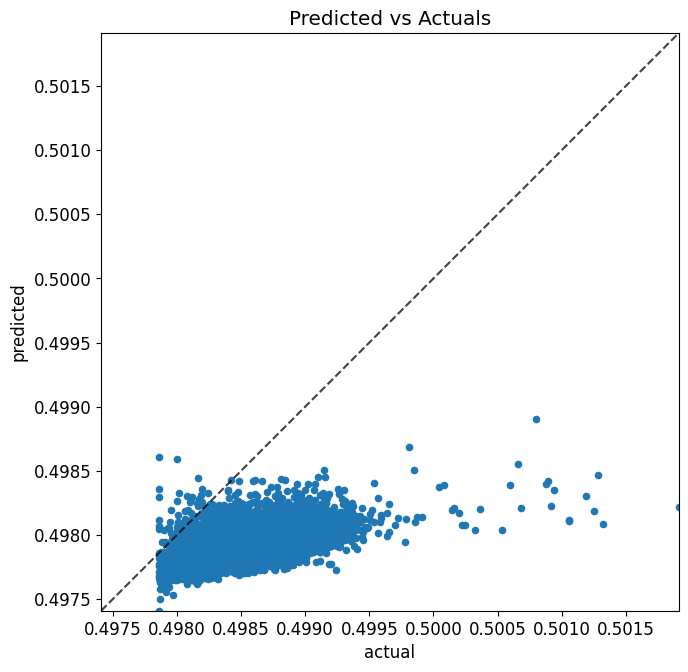

In [135]:
#mu with mae 
model = GG_NN(qm9.num_features,64, 1, 6)
model.to(device)

epochs = 150

#estimate chemical accuracy for mu
chem_accu = 0.1
loss_function = torch.nn.L1Loss()

# loss_function = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 0.001)

model, tlosses, vlosses = train_model(model, epochs, loss_function, optimizer, train_loader, val_loader)

test_out, test_y = evaluate_test(model, test_loader)

# denormalize
denorm_out = (test_out * train_std) + train_mean
denorm_y = (test_y * train_std) + train_mean

mae_val = loss_function(denorm_out, denorm_y).item()
print(f'Test loss:{mae_val:.6e}')
print(f'Error ratio:{mae_val*chem_accu}')
#print(f"Test loss:{loss_function(denorm_out, denorm_y).item():.6e}")

preds = test_out.cpu().detach().numpy()
actual = test_y.cpu().detach().numpy()

plot_pred_v_actual(preds, actual)

In [ ]:
#mu with mae 
model = GG_NN(qm9.num_features,64, 1, 6)
model.to(device)


epochs = 150

#estimate chemical accuracy for mu
chem_accu = 0.1
loss_function = torch.nn.L1Loss()

# loss_function = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 0.001)

model, tlosses, vlosses = train_model(model, epochs, loss_function, optimizer, train_loader, val_loader)

test_out, test_y = evaluate_test(model, test_loader)

# denormalize
denorm_out = (test_out * train_std) + train_mean
denorm_y = (test_y * train_std) + train_mean

mae_val = loss_function(denorm_out, denorm_y).item()
print(f'Test loss:{mae_val:.6e}')
print(f'Error ratio:{mae_val*chem_accu}')
#print(f"Test loss:{loss_function(denorm_out, denorm_y).item():.6e}")

preds = test_out.cpu().detach().numpy()
actual = test_y.cpu().detach().numpy()

plot_pred_v_actual(preds, actual)

In [167]:
import torch_geometric.nn.conv.gated_graph_conv as gg_nn
from torch_geometric.nn import Set2Set
class GG_NN_Stack(torch.nn.Module):
    def __init__(self, in_channels, hidden_dim, num_layers):
        super().__init__()
        self.input_lin = Linear(in_channels, hidden_dim)
        #have a list of layers of GGNN
        self.layers = torch.nn.ModuleList([gg_nn.GatedGraphConv(hidden_dim, 1) for i in range(num_layers)])
        self.relu = torch.nn.ReLU()
    def forward(self, x, edge_index):
        x = self.input_lin(x)
        for ggnn in self.layers:
            x = ggnn(x, edge_index)
            x = self.relu(x)
        return x

class GG_NN(torch.nn.Module):
    def __init__(self, in_channels, hidden_dim, out_dim, num_layers):
        super().__init__()
        self.gg_nn_stack = GG_NN_Stack(in_channels, hidden_dim, num_layers)
        self.lin1 = Linear(hidden_dim, hidden_dim)
        self.lin2 = Linear(hidden_dim, out_dim)
        self.relu = torch.nn.ReLU()
        self.set2set = Set2Set(hidden_dim, 3)

    def forward(self, data):
        x = data.x
        edge_index = data.edge_index
        batch = data.batch

        x = self.gg_nn_stack(x, edge_index)
        x = global_mean_pool(x, batch)
        #x = self.set2set(x, batch)
        x = self.relu(self.lin1(x))
        x = self.lin2(x)
        return x
    

Epoch 0: training loss:7.351342e-03, validation loss:1.550045e-03
Epoch 50: training loss:1.058902e-03, validation loss:1.310993e-03
Epoch 100: training loss:9.266904e-04, validation loss:5.745280e-04
Epoch 149: training loss:4.284240e-04, validation loss:4.184237e-04
4.153416e-04
Test loss:1.919348e+00
Error ratio:0.19193483591079713


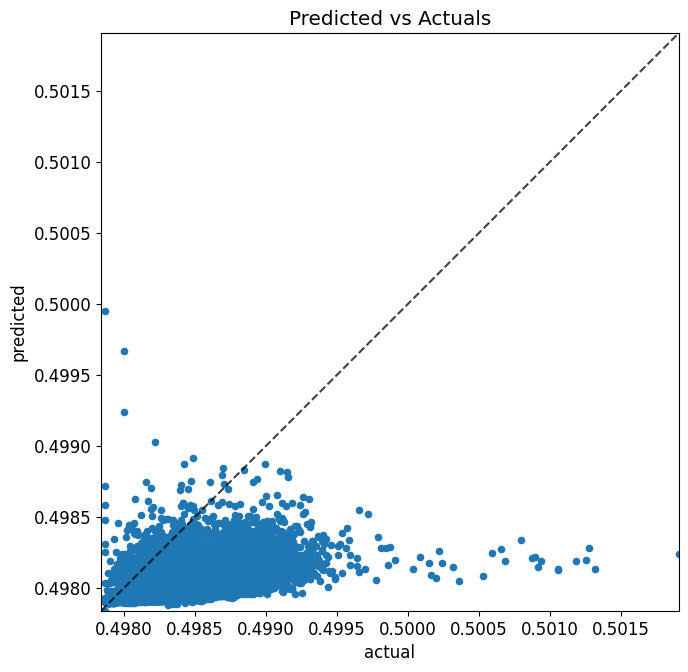

In [168]:
model = GG_NN(qm9.num_features,128, 1, 5)
model.to(device)


epochs = 150

#estimate chemical accuracy for mu
chem_accu = 0.1
loss_function = torch.nn.L1Loss()

optimizer = torch.optim.Adam(model.parameters(), lr = 0.001)

model, tlosses, vlosses = train_model(model, epochs, loss_function, optimizer, train_loader, val_loader)

test_out, test_y = evaluate_test(model, test_loader)

# denormalize
denorm_out = (test_out * train_std) + train_mean
denorm_y = (test_y * train_std) + train_mean

mae_val = loss_function(denorm_out, denorm_y).item()
print(f'Test loss:{mae_val:.6e}')
print(f'Error ratio:{mae_val*chem_accu}')

preds = test_out.cpu().detach().numpy()
actual = test_y.cpu().detach().numpy()

plot_pred_v_actual(preds, actual)